<a href="https://colab.research.google.com/github/Tuanajax/CFA-AI-Journey/blob/main/CFA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/Tuanajax/CFA-AI-Journey.git

Cloning into 'CFA-AI-Journey'...
remote: Enumerating objects: 32, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 32 (delta 10), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (32/32), 18.40 KiB | 495.00 KiB/s, done.
Resolving deltas: 100% (10/10), done.


In [2]:
!pip install -U vnstock


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 kB 828.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 279.7/279.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.3/48.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 5.3 MB/s eta 0:00:00


In [3]:
from vnstock import register_user
register_user()



  VNSTOCK - ĐĂNG KÝ API KEY

🚀 Đăng ký API key để tăng giới hạn sử dụng (🚀 Register API key to increase rate limits):

  • Khách (Guest): 20 requests/phút - không cần đăng ký (20 requests/min - no registration needed)
  • Cộng đồng (Community): 60 requests/phút - đăng ký miễn phí (60 requests/min - free registration)
  • Tài trợ (Sponsor): 180-600 requests/phút (180-600 requests/min)

📌 Đăng nhập Google để tạo tài khoản và lấy API key miễn phí tại: https://vnstocks.com/login (Login with Google to create an account and get a free API key at: https://vnstocks.com/login)


Nhập API key của bạn: vnstock_cf3ba8c5d21a8e84656fcf3acb40b567
✓ API key đã được lưu thành công! (API key saved successfully!)
Bạn đang sử dụng Phiên bản cộng đồng (60 requests/phút)
(You are using Community version - 60 requests/minute)

Để tham gia gói thành viên tài trợ (To join sponsor membership):
  Truy cập: https://vnstocks.com/insiders-program

✓ API key đã được lưu thành công! (✓ API key saved successfully!) v

True

In [4]:
from vnstock import Listing, Quote, Company, Finance, Trading


In [5]:
from vnstock import Listing
listing = Listing(source='KBS')

In [14]:
listing.symbols_by_exchange()

,symbol,organ_name,en_organ_name,exchange,type,id
0,TCB,Ngân hàng TMCP Kỹ thương Việt Nam,Vietnam Technological and Commercial Joint Sto...,HOSE,stock,1
1,VGI,Tổng Công ty cổ phần Đầu tư Quốc tế Viettel,Viettel Global Investment Joint Stock Company,UPCOM,stock,1
2,VKP,CTCP Nhựa Tân Hóa,Viky Plastic Joint Stock Company,UPCOM,stock,1
3,AGM,CTCP Xuất Nhập khẩu An Giang,An Giang Import - Export Company,UPCOM,stock,1
4,BKC,CTCP Khoáng sản Bắc Kạn,Bac Kan Mineral Joint Stock Corporation,HNX,stock,1
...,...,...,...,...,...,...
3237,HDB12507,NaN,NaN,NaN,corpbond,7
3238,OCB12528,NaN,NaN,NaN,corpbond,7
3239,VKT12101,NaN,NaN,NaN,corpbond,7
3240,DRT12401,NaN,NaN,NaN,corpbond,7


In [22]:
from vnstock import Quote
from datetime import datetime
import pandas as pd

now = datetime.now()
today = now.strftime("%Y-%m-%d")
quote = Quote(symbol='TCB', source='KBS')
df = quote.history(start='2024-01-01', end=today, interval='d')

# Convert 'time' to datetime and set as index
df['time'] = pd.to_datetime(df['time'])
df = df.set_index('time')

# Resample to monthly frequency and take the last close price of the month
monthly_close = df['close'].resample('ME').last()

# Calculate Month-over-Month (MoM) percentage change
mom_change = monthly_close.pct_change() * 100

print("Thay đổi giá TCB theo tháng (MoM):")
print(mom_change.dropna())

Thay đổi giá TCB theo tháng (MoM):
time
2024-02-29    22.152691
2024-03-31    12.704918
2024-04-30    -2.000000
2024-05-31     3.988868
2024-06-30    -0.624442
2024-07-31    -0.448833
2024-08-31     0.450857
2024-09-30     3.635548
2024-10-31    -1.255955
2024-11-30    -1.228070
2024-12-31     4.440497
2025-01-31     0.425170
2025-02-28     5.419136
2025-03-31     5.381526
2025-04-30    -4.382622
2025-05-31    15.783181
2025-06-30    12.323580
2025-07-31    -0.582286
2025-08-31    16.461159
2025-09-30    -1.879301
2025-10-31    -7.256542
2025-11-30    -3.839442
2025-12-31     3.387780
2026-01-31     2.867174
2026-02-28     0.967008
2026-03-31   -15.295775
2026-04-30    10.242767
2026-05-31    -3.318250
Freq: ME, Name: close, dtype: float64


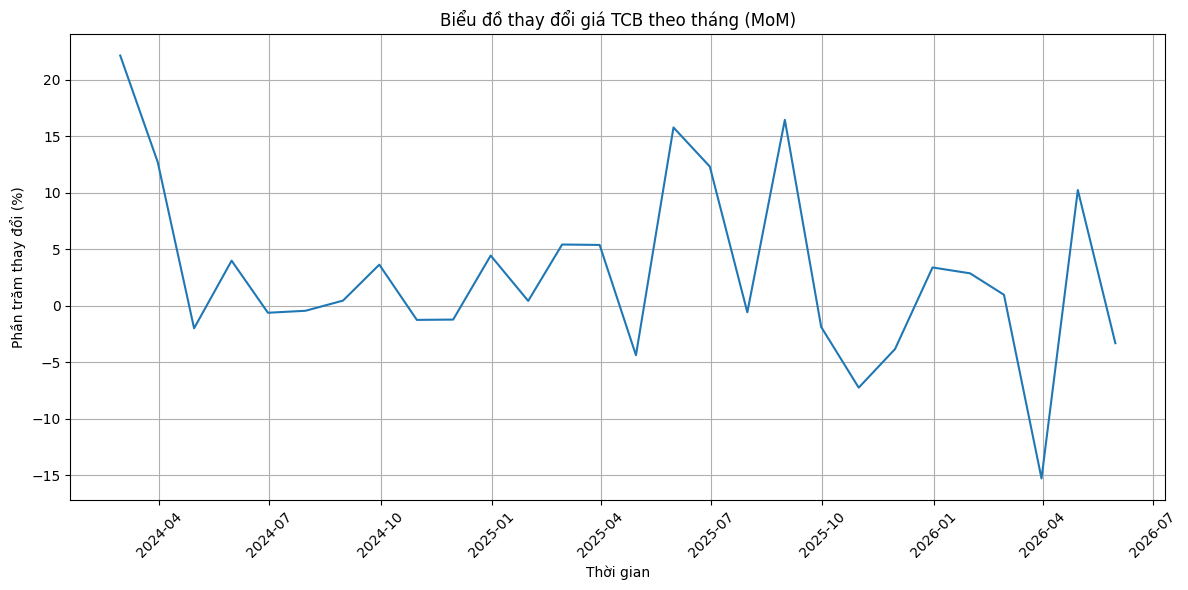

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(x=mom_change.index, y=mom_change.values)
plt.title('Biểu đồ thay đổi giá TCB theo tháng (MoM)')
plt.xlabel('Thời gian')
plt.ylabel('Phần trăm thay đổi (%)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
# Calculate the correlation between 'close' price and 'volume'
correlation = df['close'].corr(df['volume'])

print(f"Hệ số tương quan giữa giá đóng cửa và khối lượng giao dịch của TCB là: {correlation:.4f}")

Hệ số tương quan giữa giá đóng cửa và khối lượng giao dịch của TCB là: 0.3448


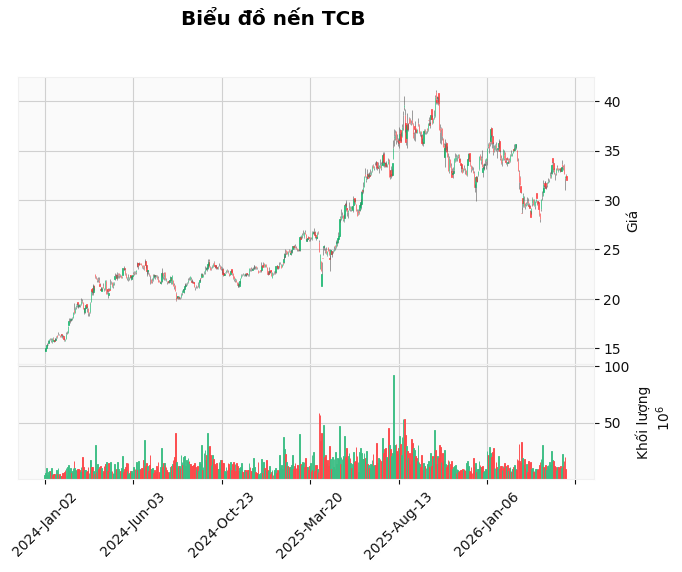

In [24]:
import mplfinance as mpf

# Create a candlestick chart
fig, axes = mpf.plot(df, type='candle', style='yahoo', volume=True,
                     title='Biểu đồ nến TCB',
                     ylabel='Giá',
                     ylabel_lower='Khối lượng',
                     returnfig=True)

plt.show()